[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HumbertoDiego/cdg-ime/blob/main/Prospecção.ipynb)

# Ciência de Dados Geoespaciais - Prospecção

**Maj Diego - 2° Semestre / 2026**

**Objetivos**

1. Conceituar ciência de dados;
2. Especificar dados para análise;
3. Identificar datasets públicos;
4. Conceituar API e como ser cliente de uma API;
5. Conceituar Geoserviços OGC e como ser cliente de um WFS/WMS/WMTS;

## 1. Conceituar ciência de dados

**Ciência de Dados** é um campo interdisciplinar que combina estatística, computação e conhecimento de domínio para extrair conhecimento e insights a partir de dados estruturados e não estruturados.

### **1.1 O que é Ciência de Dados Geoespaciais?**

A **Ciência de Dados Geoespaciais** aplica os métodos de ciência de dados a dados que possuem **componente espacial** — ou seja, dados que podem ser referenciados a um local na superfície terrestre.

Exemplos de perguntas que ela responde:
- Onde há maior risco de deslizamento de encosta?
- Como a temperatura urbana varia em função da cobertura vegetal?
- Quais regiões apresentam maior vulnerabilidade logística?

### **1.2 O pipeline de ciência de dados**

| Etapa | Descrição | Ferramentas comuns |
|-------|-----------|--------------------|
| **Prospecção** | Identificar e coletar dados | APIs, web scraping, portais abertos |
| **Tratamento/Pré-processamento** | Limpar, transformar e integrar | pandas, geopandas, GDAL |
| **Exploração/Mineração** | Analisar estatísticas e visualizar | matplotlib, seaborn, folium |
| **Modelagem** | Aplicar algoritmos e modelos | scikit-learn, statsmodels |
| **Análise do resultado** | Apresentar resultados | dashboards, mapas, relatórios |


### **1.3 A importância da pergunta**

Antes de coletar qualquer dado, é essencial formular uma **pergunta clara e mensurável**. Perguntas vagas levam a coletas desnecessárias e análises sem foco.

| Pergunta vaga | Pergunta bem formulada |
|--------------|------------------------|
| "Onde há crime?" | "Qual a densidade de ocorrências de roubo por km² nos bairros do Rio de Janeiro em 2023?" |
| "Como está o trânsito?" | "Qual o tempo médio de deslocamento entre Niterói e o Centro do Rio às 8h nos dias úteis?" |

## 2. Especificar dados para análise

### **2.1 Tipos de dados quanto à estrutura**

| Tipo | Descrição | Exemplo |
|------|-----------|----------|
| **Estruturado** | Organizado em tabelas com schema fixo | Censo IBGE em .csv |
| **Semi-estruturado** | Tem organização, mas sem schema rígido | JSON de API, XML |
| **Não estruturado** | Sem organização predefinida | Texto livre, imagens de satélite |

### **2.2 Tipos de dados geoespaciais**

<img src="media/imgs/raster_vetor.png">

#### **2.2.1 Modelo vetorial**

Dados vetoriais são tipologias de dados espaciais que representam o espaço geográfico por meio de pontos, linhas ou polígonos. Ao contrário dos dados raster, eles não representam o espaço geográfico de forma contínua, mas sim, delimitada. 

**Exercício**
Quais destas primitivas vetoriais você escolheria para representar estes elementos espaciais: *localidades, estações, ocorrências, rios, rodovias, redes de transporte, área do municípios, bacias hidrográficas e lotes*.

- **Ponto**: ?
- **Linha**: ?
- **Polígono**: ? 

Existem ainda situações que um geo-objeto pode assumir mais de uma primitiva, a ET-EDGV as nomeia como classes `complexas`. 




**As primitivas vetoriais são plotadas, como coordenadas em um gráfico:**

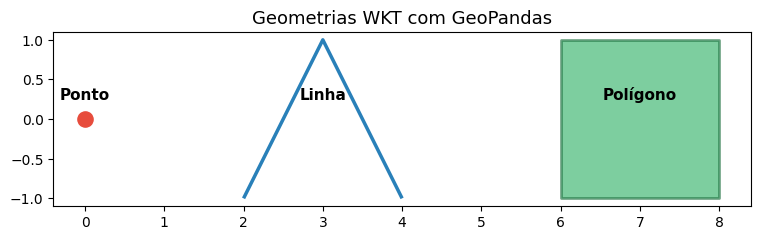

    tipo                                        wkt
   Ponto                                POINT (0 0)
   Linha LINESTRING (2 -1, 2.5 0, 3 1, 3.5 0, 4 -1)
Polígono     POLYGON ((6 -1, 8 -1, 8 1, 6 1, 6 -1))


In [ ]:
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt

# ── Geometrias em WKT ────────────────────────────────────────
ponto   = wkt.loads("POINT (0 0)")
linha   = wkt.loads("LINESTRING (2 -1, 2.5 0, 3 1, 3.5 0, 4 -1)")
poligono = wkt.loads("POLYGON ((6 -1, 8 -1, 8 1, 6 1, 6 -1))")

# ── GeoDataFrame com os três tipos ───────────────────────────
gdf = gpd.GeoDataFrame(
    {
        "tipo"  : ["Ponto", "Linha", "Polígono"],
        "wkt"   : [ponto.wkt, linha.wkt, poligono.wkt],
        "geometry": [ponto, linha, poligono],
    },
    crs="EPSG:4326",
)

# ── Plot ──────────────────────────────────────────────────────
cores = ["#e74c3c", "#2980b9", "#27ae60"]

fig, ax = plt.subplots(figsize=(9, 4))

# Polígono (fundo + borda)
gdf[gdf.geom_type == "Polygon"].plot(
    ax=ax, color="#27ae60", edgecolor="#1a6e3c", linewidth=2, alpha=0.6, label="Polígono"
)
# Linha
gdf[gdf.geom_type == "LineString"].plot(
    ax=ax, color="#2980b9", linewidth=2.5, label="Linha"
)
# Ponto
gdf[gdf.geom_type == "Point"].plot(
    ax=ax, color="#e74c3c", markersize=120, zorder=5, label="Ponto"
)

# Rótulos de tipo sobre cada geometria
for _, row in gdf.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.annotate(row["tipo"], xy=(cx, cy), xytext=(0, 14),
                textcoords="offset points", ha="center",
                fontsize=11, fontweight="bold")

ax.set_title("Geometrias WKT com GeoPandas", fontsize=13)
plt.show()

# ── Inspecionar WKTs ─────────────────────────────────────────
print(gdf[["tipo", "wkt"]].to_string(index=False))

#### **2.2.2 Ferramentas para construção de uma geoinformação vetorial**

[**Well Known Text (WKT)**](https://wktmap.com/): As geometrias textuais WKT são usadas em todas as especificações OGC e estão presentes em aplicações que implementam essas especificações (GDAL OGR, PostGIS, geopandas, ... ) tornando possível converter geometrias *para* e *de* uma representação WKT.

As coordenadas para geometrias podem ser 2D (x, y), 3D (x, y, z), 4D (x, y, z, m) com um valor m que faz parte de um sistema de referenciamento linear ou 2D com um valor m (x, y, m), por exemplo:

As três primitivas básicas:
- Ponto `POINT (0 0)` 
- Linha `LINESTRING (2 -1, 2.5 0, 3 1, 3.5 0, 4 -1)` 
- Polígono `POLYGON ((6 -1, 8 -1, 8 1, 6 1, 6 -1))` $\leftarrow$ ponto final = ponto inicial 

As derivações básicas:
- Ponto-3D `POINT Z (0 0 0)` 
- Linha-3D `LINESTRING Z (2 -1 0, 2.5 0 0, 3 1 0, 3.5 0 0, 4 -1 0)` 
- Polígono-3D `POLYGON Z (6 -1 0, 8 -1 0, 8 1 0, 6 1 0, 6 -1 0)` 
- Multi-Ponto `MULTIPOINT  ((0 0),(1 1))`
- Multi-Linha `MULTILINESTRING  ((2 -1, 2 0, 3 1, 3 0, 4 -1), (0 0, 1 1, 3 -1, 3 0, 4 1))`
- Multi-Polígono `MULTIPOLYGON ((6 -1, 8 -1, 8 1, 6 1, 6 -1), (6 -1, 8 -1, 8 1, 6 1, 6 -1))`
- Coleção-Geométrica: `GEOMETRYCOLLECTION (POINT (40 10),LINESTRING (10 10, 20 20, 10 40), POLYGON ((40 40, 20 45, 45 30, 40 40)))`

E muitas outras:
- CircularString, CompoundCurve, CurvePolygon, MultiCurve, MultiSurface, Curve, Surface, PolyhedralSurface, TIN, Triangle, Circle, GeodesicString, EllipticalCurve, NurbsCurve, Clothoid, SpiralCurve, CompoundSurface, BrepSolid, AffinePlacement.

#### **2.2.2 Ferramentas para construção de uma geoinformação vetorial**

[**GeoJSON**](https://geojson.io/#map=3.8/-12.97/-53.94): Um formato textual para codificar uma variedade de estruturas de dados geográficos baseado em JavaScript Object Notation (JSON). Usado para representar características geográficas simples, juntamente com seus atributos não espaciais. Também é amplamente usado em mapas web (Leaflet, Mapbox, Google Maps), APIs de geolocalização e ferramentas como QGIS.

O GeoJSON suporta vários tipos de geometria, como Ponto, Linha, Polígono, Multiponto, Multilinha, Multipolígono e Coleção de Geometrias. Cada geo-objeto (GeoJSON *feature*) pode ter propriedades adicionais informando uma determinada característica.

Exemplo de GeoJSON:

```json
{
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "geometry": {
        "type": "Point",
        "coordinates": [-43.1729, -22.9068]
      },
      "properties": {"nome": "Cristo Redentor", "categoria": "monumento" }
    },
    {
      "type": "Feature",
      "geometry": {
        "type": "LineString",
        "coordinates": [[-43.18, -22.9], [-43.18, -22.9], [-43.18, -22.9]]
      },
      "properties": {"nome": "Caminho até o Cristo", "tipo": "trilha" }
    }
  ]
}
```

#### **2.2.3 Modelo raster**

Representa dados como uma grade regular de células (pixels), cada uma com um valor:
- Imagens de satélite (Landsat, Sentinel)
- Modelos Digitais de Elevação (MDE)
- Grades climáticas (temperatura, precipitação)

Esse modelo também é chamado de modelo matricial. Uma fotografia como a conhecemos é apenas 3 matrizes empilhadas, representando o nível de cores vermelho, verde e azul (RGB). Por exemplo uma imagem de 3x3x3:

$
I = \begin{bmatrix} 
[255, 0, 0] & [0, 255, 0] & [0, 0, 255] \\
[255, 255, 0] & [0, 255, 255] & [255, 0, 255] \\
[192, 192, 192] & [128, 128, 128] & [64, 64, 64]
\end{bmatrix}
$

É renderizada da seguinte forma:

<div><div style="display:flex;gap:0px"><div style="width:50px;height:50px;background-color:rgb(255, 0, 0)"></div><div style="width:50px;height:50px;background-color:rgb(0, 255, 0)"></div><div style="width:50px;height:50px;background-color:rgb(0, 0, 255)"></div></div><div style="display:flex;gap:0px"><div style="width:50px;height:50px;background-color:rgb(255, 255, 0)"></div><div style="width:50px;height:50px;background-color:rgb(0, 255, 255)"></div><div style="width:50px;height:50px;background-color:rgb(255, 0, 255)"></div></div><div style="display:flex;gap:0px"><div style="width:50px;height:50px;background-color:rgb(192, 192, 192)"></div><div style="width:50px;height:50px;background-color:rgb(128, 128, 128)"></div><div style="width:50px;height:50px;background-color:rgb(64, 64, 64)"></div></div></div>

**Resolução espacial do dado raster**: tamanho do pixel no terreno (GSD — Ground Sampling Distance). Ex.: 10 m → cada pixel representa no terreno um quadrado 10×10 m.

<img src="media/imgs/res-espacial-QGIS.png">

**Resolução radiométrica do dado raster**: Número de níveis de intensidade que cada pixel pode representar (quantização), normalmente em bits por banda. O valor do pixel pode variar da seguinte forma:

|Nome|Qt de bits | Valor min | Valor máx|
|-|- | - | -|
|`byte` ou `uint8`|8 bit|0|255|
|`uint16`|16 bit|0|65535|
|`uint32`|32 bit|0|4294967295|
|`uint64`|64 bit|0|2^64 - 1|
|`int8`|8 bit|-128|127|
|`int16`|16 bit|-32768|32767|
|`int32`|32 bit|-2147483648|2147483647|
|`int64`|64 bit|-2^63|2^63 - 1|
|`float16`|16 bit|−65504.0|65504.0|
|`float32`|32 bit|-3.4028235e+38|3.4028235e+38|
|`float64`|64 bit|-1.7976931348623157e+308|1.7976931348623157e+308|


**Resolução espectral do dado raster**: número e largura das bandas (p. ex. RGB, multispectral, hiperespectral). Por exemplo, as imagens da missão [**Sentinel 2**](https://sentiwiki.copernicus.eu/web/s2-mission#S2-Mission-Spatial-Resolution) possuem as seguintes bandas:

Bandas com resolução espacial 10m:

<img src="media/imgs/s2-10m.png">

Bandas com resolução espacial 20m:

<img src="media/imgs/s2-20m.png">

**Resolução espectral do dado raster**: número e largura das bandas (p. ex. RGB, multispectral, hiperespectral). Por exemplo, as imagens da missão **[Sentinel 2](https://sentiwiki.copernicus.eu/web/s2-mission#S2-Mission-Spatial-Resolution)** possuem as seguintes bandas:

Bandas com resolução espacial 60m:

<img src="media/imgs/s2-60m.png">

**Olhando mais a fundo um dado raster (`gdalinfo`)**

In [1]:
# ──── Baixar um arquivo de exemplo do Google Drive ────
# https://drive.google.com/file/d/1G7tuNW-r0uxZ25OR66MZ9su4fMk8cGKW/view?usp=sharing
import os
if not os.path.exists("JB_hiper.tif"):
    !gdown 1G7tuNW-r0uxZ25OR66MZ9su4fMk8cGKW --quiet --output JB_hiper.tif
# qgis_gdal_path = 'C:/Program Files/QGIS 3.40.4/bin'
qgis_gdal_path = 'C:/Program Files/QGIS 3.44.8/bin'
!"{qgis_gdal_path}/gdalinfo.exe" JB_hiper.tif


Driver: GTiff/GeoTIFF
Files: JB_hiper.tif
       JB_hiper.tif.aux.xml
Size is 613, 434
Coordinate System is:
PROJCRS["WGS 84 / UTM zone 23S",
    BASEGEOGCRS["WGS 84",
        DATUM["World Geodetic System 1984",
            ELLIPSOID["WGS 84",6378137,298.257223563,
                LENGTHUNIT["metre",1]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433]],
        ID["EPSG",4326]],
    CONVERSION["UTM zone 23S",
        METHOD["Transverse Mercator",
            ID["EPSG",9807]],
        PARAMETER["Latitude of natural origin",0,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8801]],
        PARAMETER["Longitude of natural origin",-45,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8802]],
        PARAMETER["Scale factor at natural origin",0.9996,
            SCALEUNIT["unity",1],
            ID["EPSG",8805]],
        PARAMETER["False easting",500000,
            LENGTHUNIT["metre",1],
            ID["EP

### **2.3 Sistema de Referência de Coordenadas (SRC/CRS)**

| EPSG | Nome | Tipo | Uso comum |
|---|---|---|---|
| `4326` | WGS 84 | Geográfico (lat/lon) | Dados globais, GPS, APIs, interoperabilidade |
| `4674` | SIRGAS 2000 | Geográfico (lat/lon) | Base nacional para IBGE, cartografia, dados oficiais |
| `3857` | WGS 84 / Pseudo-Mercator | Projetado | Mapas web (Google Maps, OpenStreetMap, Leaflet) |
| `31980` | SIRGAS 2000 / UTM zone 20S | Projetado | Mato Grosso, Rondônia, Amazonas, Roraima|
| `31981` | SIRGAS 2000 / UTM zone 21S | Projetado | Mato Grosso do Sul, Pará|
| `31982` | SIRGAS 2000 / UTM zone 22S | Projetado | Amapá, Pará, Tocantins, Goiás, São Paulo, Paraná, Santa Catarina, Rio Grande do Sul |
| `31983` | SIRGAS 2000 / UTM zone 23S | Projetado | Rio de Janeiro, Minas, Maranhão, Bahia  |
| `31984` | SIRGAS 2000 / UTM zone 24S | Projetado | Espírito Santo, Bahia, Ceará, Pernabuco, Paraíba, Rio Grande do Norte |


## 3. Identificar datasets públicos

Há uma vasta quantidade de dados geoespaciais disponíveis publicamente. Os principais repositórios estão sempre em constante transformações, outros vão ficando obsoletos ao longo do tempo, sendo importante se atualizar constantemente sobre o que há de novo em disponibilização de geoinformação.

### **3.1 Portais Brasileiros**

| Portal | URL | Conteúdo |
|--------|-----|----------|
| **IBGE** | https://geoftp.ibge.gov.br | Malhas municipais, censo, estatísticas |
| **IBGE API** | https://servicodados.ibge.gov.br | Dados censitários via API REST |
| **INPE** | http://queimadas.dgi.inpe.br <br> https://data.inpe.br/bdc/ | Focos de queimadas e imagens |
| **INDE** | https://www.inde.gov.br | Infraestrutura Nacional de Dados Espaciais |
| **BDGEX** | https://bdgex.eb.mil.br/bdgexapp | Base de dados geoespaciais do Exército Brasileiro |
| **dados.gov.br** | https://dados.gov.br | Portal central de dados abertos do governo |


### **3.2 Portais Internacionais**

| Portal | URL | Conteúdo |
|--------|-----|----------|
| **OpenStreetMap** | https://www.openstreetmap.org | Mapa colaborativo global (ruas, edificações, POIs) |
| **NASA EarthData** | https://earthdata.nasa.gov | Imagens de satélite, clima, oceanos |
| **Copernicus (ESA)** | https://www.copernicus.eu | Sentinel, dados ambientais, Europa e global |
| **Our World in Data** | https://ourworldindata.org | Dados socioeconômicos globais com API |



### **3.3 Exemplo: Baixando Malha Municipal do IBGE**

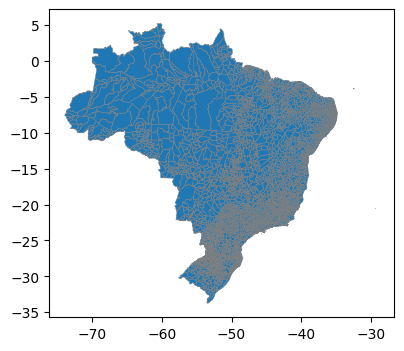

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
url_ibge = (
   "https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais"
   "/malhas_municipais/municipio_2022/Brasil/BR/BR_Municipios_2022.zip" )
municipios = gpd.read_file(url_ibge) # geopandas suporta leitura direta de .zip
municipios.plot(figsize=(5, 4), edgecolor='gray', linewidth=0.3); plt.show()

**Tabela de atributos**

In [5]:
municipios.head()

,CD_MUN,NM_MUN,SIGLA_UF,AREA_KM2,geometry
0,1100015,Alta Floresta D'Oeste,RO,7067.127,"POLYGON ((-62.00806 -12.13379, -62.00784 -12.2..."
1,1100023,Ariquemes,RO,4426.571,"POLYGON ((-63.17933 -10.13924, -63.17746 -10.1..."
2,1100031,Cabixi,RO,1314.352,"POLYGON ((-60.52408 -13.32137, -60.37162 -13.3..."
3,1100049,Cacoal,RO,3793.000,"POLYGON ((-61.35502 -11.50452, -61.35524 -11.5..."
4,1100056,Cerejeiras,RO,2783.300,"POLYGON ((-60.82135 -13.1191, -60.81773 -13.12..."


**Filtragem no Geopandas**

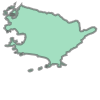

In [6]:
niteroi_boundary = municipios[municipios.NM_MUN == "Niterói"].geometry.values[0]
niteroi_boundary

## 4. Conceituar API e como ser cliente de uma API

### **4.1 O que é uma API?**

**API** (*Application Programming Interface*) é um conjunto de regras e protocolos que permite que dois sistemas de software se comuniquem. Em ciência de dados, usamos principalmente **APIs Web** baseadas no protocolo HTTP.

```
         Requisição HTTP (GET /dados?municipio=3304557)
Cliente ────────────────────────────────────────────────▶ Servidor (API)
        ◀────────────────────────────────────────────────
              Resposta HTTP 200 OK  {"populacao": 515317}
```

### **4.2 Anatomia de uma URL de API**

```
https://servicodados.ibge.gov.br/api/v1/localidades/municipios/3304557
│──────────────────────────────────────│──────────────────────│───────│
         Base URL                            Endpoint          Parâmetro
                                            (recurso)          (código IBGE)
```

### **4.3 Métodos HTTP mais comuns**

| Método | Uso | Analogia |
|--------|-----|----------|
| `GET` | Buscar/ler dados | Consultar uma ficha |
| `POST` | Enviar/criar dados | Preencher um formulário |
| `PUT` | Atualizar dados | Substituir uma ficha |
| `DELETE` | Remover dados | Apagar um registro |

<br>

> Em **ciência de dados**, usamos quase exclusivamente `GET`, pois apenas queremos *ler* dados.

### **4.4 Códigos de Status HTTP**

| Código | Significado |
|--------|-------------|
| `200 OK` | Sucesso |
| `400 Bad Request` | Parâmetro inválido na requisição |
| `401 Unauthorized` | Autenticação necessária (API Key) |
| `403 Forbidden` | Sem permissão de acesso |
| `404 Not Found` | Recurso não encontrado |
| `429 Too Many Requests` | Limite de requisições atingido |
| `500 Internal Server Error` | Erro no servidor |


### **4.5 Formatos de Resposta**

A maioria das APIs retorna dados em **JSON** (*JavaScript Object Notation*):

```json
{
  "id": 3304557,
  "nome": "Niterói",
  "microrregiao": {
    "id": 33009,
    "nome": "Rio de Janeiro"
  }
}
```

APIs geoespaciais frequentemente retornam **GeoJSON**:

```json
{
  "type": "Feature",
  "geometry": {
    "type": "Point",
    "coordinates": [-43.1033, -22.8832]
  },
  "properties": {
    "nome": "Niterói",
    "populacao": 515317
  }
}
```



### **4.6 Autenticação**

Muitas APIs exigem uma **chave de acesso (API Key)** para controle de uso:

```python
# Exemplos de autenticação

# 1. Via parâmetro na URL
url = "https://api.exemplo.com/dados?api_key=SUA_CHAVE"

# 2. Via cabeçalho (header) HTTP
headers = {"Authorization": "Bearer SUA_CHAVE"}
response = requests.get(url, headers=headers)

# Boas práticas: NUNCA coloque a chave diretamente no código!
import os
api_key = os.environ.get("MINHA_API_KEY")  # Correto
api_key = "abc123xyz"                      # Evitar
```

### **4.7 Ferramentas para efetuar requisições para uma API**

Em Python, a biblioteca padrão para fazer requisições HTTP é a `requests`. Porém, a depender do serviço, existem bibliotecas que já possuem métodos para fazer a comunicação com a API. Pode-se citar:

- [cbers4asat](https://pypi.org/project/cbers4asat/): Biblioteca Python para realizar a busca e processamento de imagens dos satélites CBERS-04A e AMAZONIA-1
- [OSMnx](https://osmnx.readthedocs.io/en/stable/index.html): Pacote em Python para baixar, modelar, analisar e visualizar facilmente redes de ruas e outras características geoespaciais do OpenStreetMap. 
- [Sentinel Hub](https://sentinelhub-py.readthedocs.io/en/latest/index.html): Serviço de imagens de satélite de big data multiespectral e multi-temporal. Os usuários podem usar a API do Sentinel Hub para recuperar dados de satélite em seus AOI e intervalos de tempo específicos.
- [CopenicusAPI](https://pypi.org/project/copernicusapi/): Um pacote para facilitar a construção interativa de consultas para o repositório do Ecossistema Copernicus Data Space.
- [geobr](https://github.com/ipeaGIT/geobr): Pacote R ou Python para baixar conjuntos oficiais do Instituto de Pesquisa Econômica Aplicada (Ipea) de dados espaciais do Brasil.

> Sempre deve-se estar atento quanto a atualização dessas bibliotecas.

### **4.8 Exemplo: API do IBGE (Localidades)**

In [7]:
# API do IBGE - Locaidades
# Documentação: https://servicodados.ibge.gov.br/api/docs/localidades
import requests
import json

# Endpoint da API de Localidades do IBGE
base, endpoint, params = "https://servicodados.ibge.gov.br/api/v1", "/localidades", "/municipios/3304557"

# Fazendo a requisição GET
url = base + endpoint + params
resposta = requests.get(url)
print(f"Status HTTP: {resposta.status_code}")
# Parseando o JSON retornado
dados = resposta.json()
print(json.dumps(dados, indent=2, ensure_ascii=False))

Status HTTP: 200
{
  "id": 3304557,
  "nome": "Rio de Janeiro",
  "microrregiao": {
    "id": 33018,
    "nome": "Rio de Janeiro",
    "mesorregiao": {
      "id": 3306,
      "nome": "Metropolitana do Rio de Janeiro",
      "UF": {
        "id": 33,
        "sigla": "RJ",
        "nome": "Rio de Janeiro",
        "regiao": {
          "id": 3,
          "sigla": "SE",
          "nome": "Sudeste"
        }
      }
    }
  },
  "regiao-imediata": {
    "id": 330001,
    "nome": "Rio de Janeiro",
    "regiao-intermediaria": {
      "id": 3301,
      "nome": "Rio de Janeiro",
      "UF": {
        "id": 33,
        "sigla": "RJ",
        "nome": "Rio de Janeiro",
        "regiao": {
          "id": 3,
          "sigla": "SE",
          "nome": "Sudeste"
        }
      }
    }
  }
}


### **4.9 Exemplo: API SIDRA — Censo 2022 (população por UF)**

In [9]:
# API do IBGE - Agregados (SIDRA)
# Tabela 9514: População residente por município (Censo 2022)
# Documentação: https://apisidra.ibge.gov.br/
import requests

url_sidra = "https://apisidra.ibge.gov.br/values/t/9514/n6/all/v/93/p/2022/d/v93 0"
resposta = requests.get(url_sidra)
resposta_dict = resposta.json()

print(f"Tamanho da resposta:\t {len(resposta_dict)}")
print("Cabeçalho:\t", resposta_dict[0])
print("Primeiro dado:")
print(json.dumps(resposta_dict[1], indent=2, ensure_ascii=False))

Tamanho da resposta:	 5571
Cabeçalho:	 {'NC': 'Nível Territorial (Código)', 'NN': 'Nível Territorial', 'MC': 'Unidade de Medida (Código)', 'MN': 'Unidade de Medida', 'V': 'Valor', 'D1C': 'Município (Código)', 'D1N': 'Município', 'D2C': 'Variável (Código)', 'D2N': 'Variável', 'D3C': 'Ano (Código)', 'D3N': 'Ano', 'D4C': 'Sexo (Código)', 'D4N': 'Sexo', 'D5C': 'Forma de declaração da idade (Código)', 'D5N': 'Forma de declaração da idade', 'D6C': 'Idade (Código)', 'D6N': 'Idade'}
Primeiro dado:
{
  "NC": "6",
  "NN": "Município",
  "MC": "45",
  "MN": "Pessoas",
  "V": "21494",
  "D1C": "1100015",
  "D1N": "Alta Floresta D'Oeste - RO",
  "D2C": "93",
  "D2N": "População residente",
  "D3C": "2022",
  "D3N": "2022",
  "D4C": "6794",
  "D4N": "Total",
  "D5C": "113635",
  "D5N": "Total",
  "D6C": "100362",
  "D6N": "Total"
}


### **4.10 Exemplo: Biblioteca OSMnx**

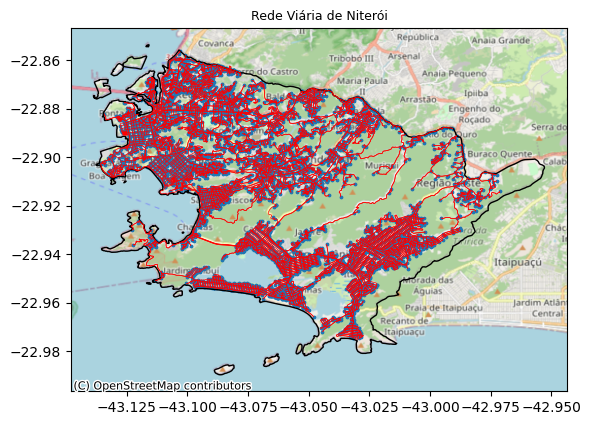

In [8]:
import osmnx as ox
import matplotlib.pyplot as plt
import contextily as cx
import geopandas as gpd
# baixar a rede viária de Niterói e onversão para GeoDataFrame
G = ox.graph_from_place("Niterói, Brasil", network_type="drive")
gdf_nodes, gdf_edges = ox.graph_to_gdfs(G)

# plotagem da rede viária
ax = gdf_nodes.plot( markersize=3, label='Nós') 
gdf_edges.plot(ax=ax, linewidth=0.5, color='red', label='Arestas')
gpd.GeoDataFrame([niteroi_boundary], columns=['geometry']).plot(ax=ax, color='none', edgecolor='black', linewidth=1, label='Limite de Niterói')

# configuração da plotagem
ax.set_title("Rede Viária de Niterói", fontsize=9)
cx.add_basemap(ax, crs=gdf_edges.crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik)
plt.show()

## 5. Conceituar geosserviços OGC e como ser cliente de um WMS/WFS/WCS

### **5.1 O que são geosserviços com o padrão do Open Geospatial Consortium (OGC)**

São serviços web que permitem coletar, armazenar, recuperar, transformar e apresentar dados espaciais, por meio do acesso a um link (URL) disponibilizado por um servidor. Os 3 padrões de geosserviços definidos pela OGC são

- **Web Map Service (WMS):** geosserviço para baixar uma representação visual de dados espaciais;
- **Web Feature Service (WFS):** permite baixar os dados geoespaciais vetoriais.
- **Web Covarage Service (WCS):** permite baixar um conjunto de dados em formato matricial, usado para representar fenômenos com variações ao longo do tempo.

### **5.2 Anatomia de uma URL de geosserviço**

<div>
<style>
    .p-service{background: #CEBBF6; color: #26215C; padding: 2px 5px; border-radius: 4px;}
    .p-version{background: #9FE1CB; color: #04342C; padding: 2px 5px; border-radius: 4px;}
    .p-request{background: #F0997B; color: #4A1B0C; padding: 2px 5px; border-radius: 4px;}
    .p-layer{background: #B5D4F4; color: #042C53; padding: 2px 5px; border-radius: 4px;}
    .p-bbox{background: #FAC775; color: #412402; padding: 2px 5px; border-radius: 4px;}
    .p-extra{background: #F4C0D1; color: #4B1528; padding: 2px 5px; border-radius: 4px;}
    .p-output{background: #C0DD97; color: #173404; padding: 2px 5px; border-radius: 4px;}
</style>
 <span>https://geoservicos.ibge.gov.br/geoserver/ows?</span>
 <span class="p-service">SERVICE=WFS</span>&amp;
 <span class="p-version">VERSION=2.0.0</span>&amp;
 <span class="p-request">REQUEST=GetFeature</span>&amp;
 <span class="p-layer">TYPENAMES=CGEO:municipio</span>&amp;
 <span class="p-bbox">SRSNAME=EPSG:4326</span>&amp;
 <span class="p-extra">COUNT=50</span>&amp;
 <span class="p-output">OUTPUTFORMAT=application/json</span>

 <ul>
<li><span class="p-service">SERVICE=WFS</span>: Identifica o protocolo. WFS entrega feições geométricas com atributos, não imagens.</li>
<li><span class="p-version">VERSION=2.0.0</span>: Versão do protocolo OGC WFS. 2.0.0 é a mais atual; 1.0.0 e 1.1.0 ainda existem.</li>
<li><span class="p-request">REQUEST=GetFeature</span>: Operação solicitada. Use GetCapabilities para descobrir camadas disponíveis.</li>
<li><span class="p-layer">TYPENAMES=CGEO:municipio</span>: Nome da camada (workspace:layer no GeoServer). Obrigatório em GetFeature.</li>
<li><span class="p-bbox" >SRSNAME=EPSG:4326</span>: Sistema de referência de coordenadas das feições retornadas. WGS-84 é o mais comum.</li>
<li><span class="p-extra" >COUNT=50</span>:Limita o número de feições retornadas. Importante para não sobrecarregar os servidores e clientes.</li>
<li><span class="p-output">OUTPUTFORMAT=application/json</span>: Formato de saída. GeoJSON é o mais compatível com Python/GeoPandas.</li>
</ul>
</div>



### **5.3 Extrato de URLs de geosserviços**

https://inde.gov.br/CatalogoGeoservicos

<img src="media/imgs/inde-ows.jpeg">

### **5.4 Exemplo: Serviços OGC da DSG**

Geosserviços da DSG disponíveis em: https://geoportal.eb.mil.br/portal/index.php/bdgex/servicos-ogc

**1º Passo**: Antes de fazer qualquer requisição, sempre comece com `GetCapabilities` — ele retorna um XML descrevendo todas as camadas disponíveis, sistemas de coordenadas suportados e formatos de saída:

<img src="media/imgs/bdgex-GetCapabilities.png" height=400>

### **5.4 Exemplo: Serviços OGC da DSG**

In [9]:
import requests
from bs4 import BeautifulSoup

url = "http://bdgex.eb.mil.br/ms25/ows?SERVICE=WFS&REQUEST=GetCapabilities"
response = requests.get(url) # Fazer a requisição

soup = BeautifulSoup(response.content, 'xml') # Parsear o XML
feature_types = soup.find_all('FeatureType') # Capturar as tags FeatureType

print(f"Total de FeatureTypes encontrados: {len(feature_types)}")
for i, ft in enumerate(feature_types, 1):
    print(f"{i}: {ft.find('Name').text} ({ft.find('Title').text})")
    if i >= 8: break

Total de FeatureTypes encontrados: 347
1: ms:Trecho_Massa_Dagua_A (Trecho_Massa_Dagua_A)
2: ms:Edif_Saude_A (Edif_Saude_A)
3: ms:Cidade_P (Cidade_P)
4: ms:Identificador_Trecho_Rodoviario_P (Identificador_Trecho_Rodoviario_P)
5: ms:Galeria_Bueiro_P (Galeria_Bueiro_P)
6: ms:Area_Edificada_A (Area_Edificada_A)
7: ms:Nome_Local_P (Nome_Local_P)
8: ms:Trecho_Drenagem_L (Trecho_Drenagem_L)


### **5.4 Exemplo: Serviços OGC da DSG**

In [28]:
from urllib.parse import urlencode
import geopandas as gpd
import requests
import io

# Parâmetros da requisição
params = {
    "SERVICE": "WFS",
    "VERSION": "2.0.0",
    "REQUEST": "GetFeature",
    "TYPENAMES": "ms:Trecho_Massa_Dagua_A", # camada
    "SRSNAME": "EPSG:4326",
    "COUNT": 100,                          # limite de feições
    "OUTPUTFORMAT": "application/gml+xml; version=3.2",
    # Filtro espacial por BBOX (minX, minY, maxX, maxY)
    "BBOX": "-125, -55, 0, 15,EPSG:4326",
}
base_url = 'http://bdgex.eb.mil.br/ms25/ows'
url = f"{base_url}?{urlencode(params)}"
response = requests.get(url, verify=False)
# Load the content into GeoPandas
gdf = gpd.read_file(io.BytesIO(response.content))
gdf.head(2)

d:\SE6\CDG\git\cdg-ime\.venv\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'bdgex.eb.mil.br'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


,gml_id,lowerCorner,upperCorner,gid,geometriaAproximada,tipoMassaDagua,regime,salinidade,tipoTrechoMassa,metadataid,nomeAbrev,nome,geometry
0,Trecho_Massa_Dagua_A.3458,-25.384451 -49.428789,-25.384028 -49.427876,3458,0.0,Desconhecida,Permanente,Desconhecida,Represa/Açude,a1837703-efc9-5576-5eb1-ed2597e9f4a2,NaN,NaN,"POLYGON ((-49.42788 -25.3841, -49.42788 -25.38..."
1,Trecho_Massa_Dagua_A.1185,-27.370141 -51.282787,-27.368836 -51.281509,1185,0.0,Desconhecida,Permanente,Desconhecida,Represa/Açude,6d415ff1-c965-400f-afb1-b5340e6e9c80,w,NaN,"POLYGON ((-51.28249 -27.36985, -51.28279 -27.3..."


## Complemento

### Webscrapping: Obtendo dados sem API.


## Lista de exercícios complementares

**Exercício 1.** Acesse a API do IBGE (`servicodados.ibge.gov.br`) e obtenha a lista de todos os municípios do estado do Rio de Janeiro. Quantos são?

**Exercício 2.** Utilizando a API SIDRA do IBGE (tabela 9514), obtenha a população de todos os municípios fluminenses no Censo 2022. Qual o município mais populoso? E o menos populoso?

**Exercício 3.** Faça o download da malha municipal do estado do RJ via `geoftp.ibge.gov.br`. Plote um mapa colorindo os municípios por população (use os dados do Exercício 2).

**Exercício 4.** Usando a Overpass API, obtenha a localização de todas as escolas (`amenity=school`) da cidade de Niterói. Quantas foram encontradas? Plote-as em um mapa.

**Exercício 5.** Utilize `pd.read_html()` para extrair a tabela de municípios do Rio de Janeiro da Wikipedia e compare com os dados obtidos via API do IBGE. Há diferenças? Quais?

**Exercício 6.** Crie uma função Python que, dado o nome de uma cidade brasileira, retorne um dicionário com: código IBGE, população (Censo 2022), área territorial e UF. Use a API do IBGE.

## Lista de exercícios suplementares

**Exercício S1.** Utilizando a API do INMET (`apitempo.inmet.gov.br`), obtenha os dados de precipitação acumulada das estações automáticas do estado do RJ para os últimos 30 dias. Qual estação registrou maior precipitação?

**Exercício S2.** Acesse o portal de dados abertos do DNIT e faça o download do shapefile de rodovias federais do Brasil. Calcule a extensão total (km) das rodovias federais que passam pelo estado do Rio de Janeiro.

**Exercício S3.** Usando `osmnx`, obtenha a rede viária (modo `drive`) de um bairro de sua escolha. Calcule: número de nós, número de arestas e extensão total da malha em km.

**Exercício S4 (desafio).** Construa um pipeline automatizado que:
1. Baixa dados populacionais dos municípios do RJ (API IBGE)
2. Baixa a malha municipal (IBGE geoftp)
3. Faz o join espacial entre geometria e população
4. Gera um mapa coroplético interativo com `folium`
5. Salva o resultado em um arquivo HTML

**Exercício S5 (desafio).** Implemente um web scraper ético que colete dados de uma tabela de um portal público de sua escolha (ex.: dados de licitações, notas fiscais ambientais, registros de queimadas). Inclua: tratamento de erros, respeito ao `robots.txt`, e pausa entre requisições.

<!-- **Exercicio 6 gabarito:**

```python
import numpy as np

a = np.array([3.0, 4.25, 5.5, 8.0])
l = np.array([4.5, 4.25, 5.5, 5.5])

# Cálculo do coeficiente angular (m) e intercepto (b)
A = np.vstack([a, np.ones(len(a))]).T

# X = [m, b]
X_a = np.linalg.inv(A.T @ A) @ A.T @ l
X_a, np.linalg.lstsq(A, l)[0]
``` -->

<!-- **Exercicio 7 gabarito:** (mantido original) -->

<!-- **Exercicio 14 gabarito** (mantido original) -->

<!-- **Exercício 15 gabarito** (mantido original) -->